# Filtros Activos con Amplificadores Operacionales

Orden del filtro: N = 2
Frecuencias normalizadas Wn = [5026.54824574 7853.98163397]


/home/mateod/.local/lib/python3.10/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


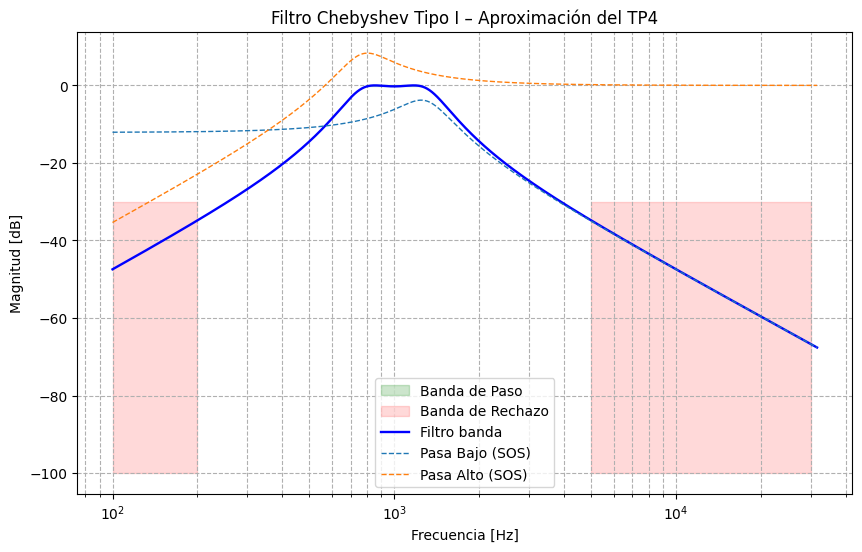

In [1]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
#  PARAMETROS DEL PROBLEMA (PLANTILLA DEL TP4)
# =========================================================

fp = [800, 1250]      # Banda de paso [Hz]
fs = [200, 5000]      # Banda de rechazo [Hz]

Wp = 2*np.pi*np.array(fp)   # rad/s
Ws = 2*np.pi*np.array(fs)   # rad/s

Ap = 0.25     # Max ripple en banda de paso [dB]
As = 30       # Mínima atenuación en banda de rechazo [dB]

# =========================================================
# 1.1 – Aproximación de Chebyshev Tipo I
# =========================================================

# Orden mínimo (cheb1ord)
N, Wn = signal.cheb1ord(Wp, Ws, Ap, As, analog=True)
print(f"Orden del filtro: N = {N}")
print(f"Frecuencias normalizadas Wn = {Wn}")

# Coeficientes del filtro pasa banda
b, a = signal.cheby1(N, Ap, Wn, btype='bandpass', analog=True, output='ba')

# Función de transferencia
Filtro = signal.TransferFunction(b, a)

# =========================================================
# Secciones de segundo orden (bicuadráticas)
# =========================================================

sos = signal.cheby1(N, Ap, Wn, btype="bandpass", analog=True, output="sos")

# Cada fila de sos = [b0 b1 b2 a0 a1 a2]
PasaBajo = signal.TransferFunction( sos[0,:3], sos[0,3:] )
PasaAlto = signal.TransferFunction( sos[1,:3], sos[1,3:] )

# =========================================================
# RESPUESTAS EN FRECUENCIA
# =========================================================

f = np.logspace(2, 4.5, 5000)  # 100 Hz a 30 kHz
w = 2*np.pi*f

_, h_F = signal.freqs(b, a, w)
_, h_PB = signal.freqs(PasaBajo.num, PasaBajo.den, w)
_, h_PA = signal.freqs(PasaAlto.num, PasaAlto.den, w)

# =========================================================
# GRAFICO DEL FILTRO + PLANTILLA
# =========================================================

plt.figure(figsize=(10,6))

# Plantilla – Banda de Paso
plt.fill_between([fp[0], fp[1]], [-Ap, -Ap], [-0.01, -0.01],
                 color='green', alpha=0.2, label='Banda de Paso')

# Plantilla – Banda de Rechazo (izquierda)
plt.fill_between([100, fs[0]], [-100, -100], [-As, -As],
                 color='red', alpha=0.15)

# Plantilla – Banda de Rechazo (derecha)
plt.fill_between([fs[1], 30000], [-As, -As], [-100, -100],
                 color='red', alpha=0.15, label='Banda de Rechazo')

# Respuesta del filtro
plt.semilogx(f, 20*np.log10(abs(h_F)), label="Filtro banda", color='b', linewidth=1.7)
plt.semilogx(f, 20*np.log10(abs(h_PB)), '--', label="Pasa Bajo (SOS)", linewidth=1)
plt.semilogx(f, 20*np.log10(abs(h_PA)), '--', label="Pasa Alto (SOS)", linewidth=1)

plt.grid(which='both', ls='--')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Filtro Chebyshev Tipo I – Aproximación del TP4")
plt.legend()
plt.show()


Orden del filtro: N = 2
Frecuencias de corte (rad/s) Wn = [5026.54824574 7853.98163397]

==== Filtro banda(s) ====
Numerador:
           2
1.642e+07 x
Denominador:
   4        3             2
1 x + 5080 x + 9.586e+07 x + 2.006e+11 x + 1.559e+15

==== PasaBajo (SOS)(s) ====
Numerador:
 
1.642e+07
Denominador:
   2
1 x + 3184 x + 6.632e+07

==== PasaAlto (SOS)(s) ====
Numerador:
   2
1 x
Denominador:
   2
1 x + 1896 x + 2.35e+07



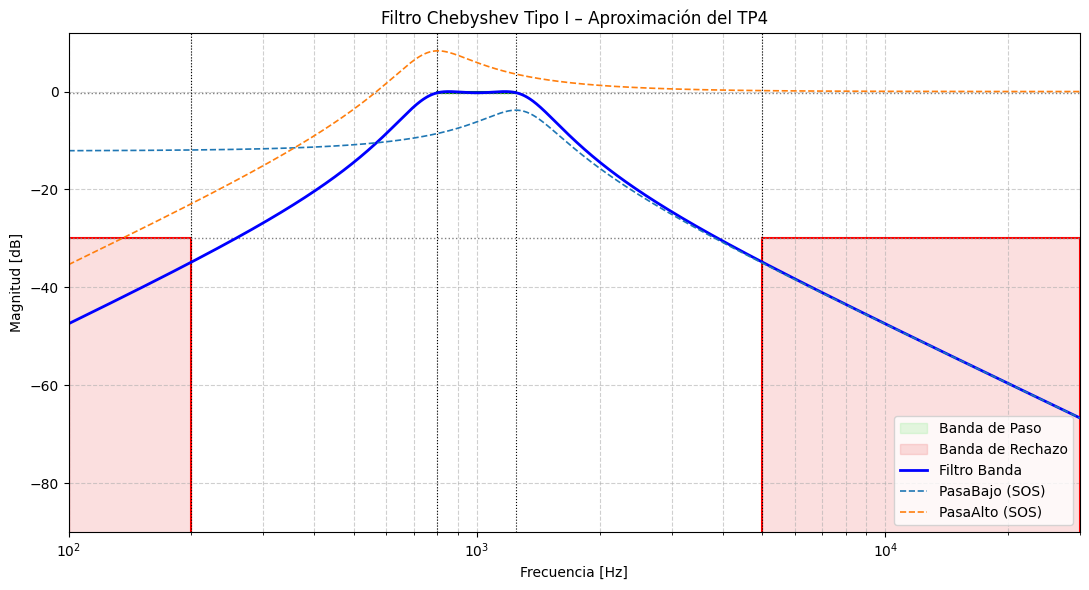

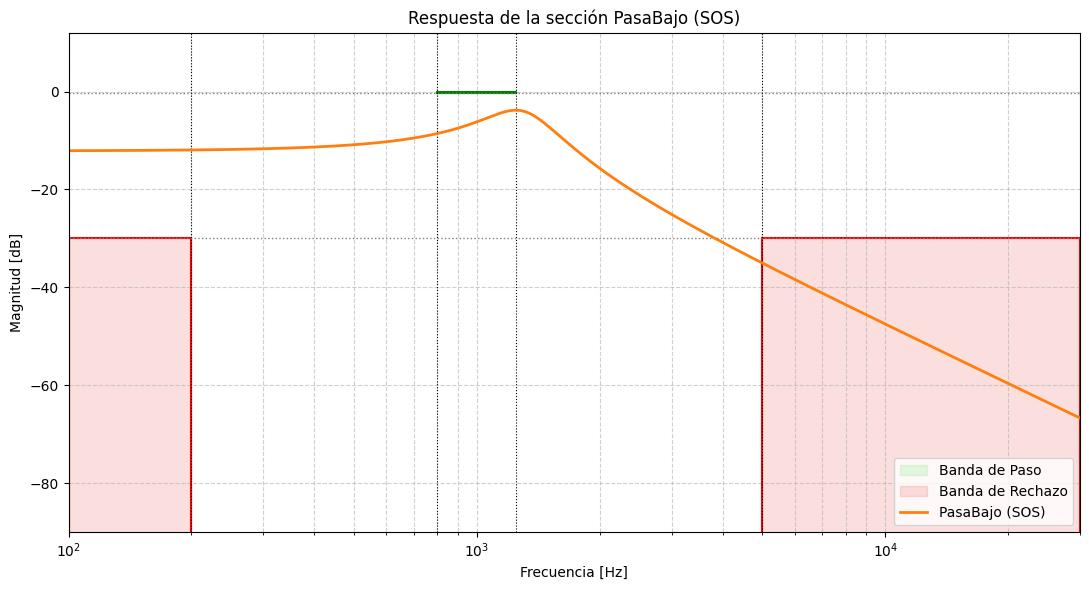

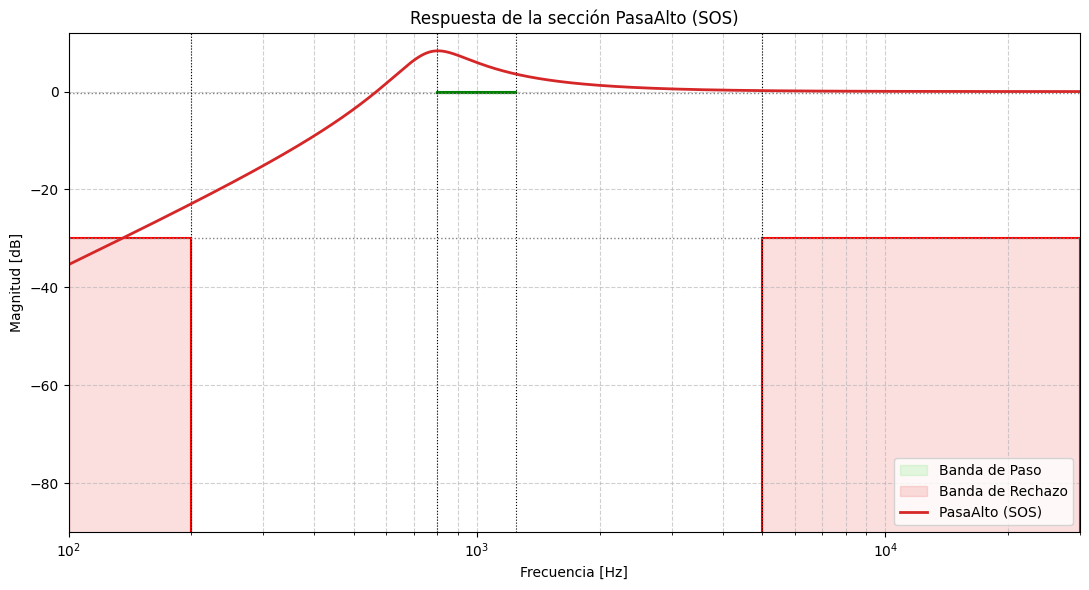

In [2]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
#  PARAMETROS DEL PROBLEMA (PLANTILLA DEL TP4)
# =========================================================

fp = [800, 1250]      # Banda de paso [Hz]
fs = [200, 5000]      # Banda de rechazo [Hz]

Wp = 2*np.pi*np.array(fp)   # rad/s
Ws = 2*np.pi*np.array(fs)   # rad/s

Ap = 0.25     # Max ripple en banda de paso [dB]
As = 30       # Mínima atenuación en banda de rechazo [dB]

# =========================================================
# 1.1 – Aproximación de Chebyshev Tipo I
# =========================================================

N, Wn = signal.cheb1ord(Wp, Ws, Ap, As, analog=True)
print(f"Orden del filtro: N = {N}")
print(f"Frecuencias de corte (rad/s) Wn = {Wn}\n")

b, a = signal.cheby1(N, Ap, Wn, btype='bandpass', analog=True, output='ba')
Filtro = signal.TransferFunction(b, a)

# =========================================================
# Secciones de segundo orden (bicuadráticas)
# =========================================================
sos = signal.cheby1(N, Ap, Wn, btype="bandpass", analog=True, output="sos")

PasaBajo = signal.TransferFunction(sos[0, :3], sos[0, 3:])
PasaAlto = signal.TransferFunction(sos[1, :3], sos[1, 3:])

# =========================================================
# IMPRESION DE FUNCIONES DE TRANSFERENCIA
# =========================================================
def print_tf(tf, name):
    print(f"==== {name}(s) ====")
    print("Numerador:")
    print(np.poly1d(tf.num))
    print("Denominador:")
    print(np.poly1d(tf.den))
    print()

print_tf(Filtro,   "Filtro banda")
print_tf(PasaBajo, "PasaBajo (SOS)")
print_tf(PasaAlto, "PasaAlto (SOS)")

# =========================================================
# RESPUESTAS EN FRECUENCIA
# =========================================================
f = np.logspace(2, 4.5, 5000)  # 100 Hz a 30 kHz
w = 2*np.pi*f

_, h_F  = signal.freqs(b, a, w)
_, h_PB = signal.freqs(PasaBajo.num, PasaBajo.den, w)
_, h_PA = signal.freqs(PasaAlto.num, PasaAlto.den, w)

# =========================================================
# FUNCION AUXILIAR: PLANTILLA CON RECTANGULOS
# =========================================================
def add_template(ax):
    # Rango de magnitudes para los rectángulos
    y_min = -100
    y_max = 0

    # --- Banda de paso: rectángulo verde ---
    ax.fill_between([fp[0], fp[1]], -Ap, 0,
                    color='lightgreen', alpha=0.25, label='Banda de Paso')
    ax.plot([fp[0], fp[1], fp[1], fp[0], fp[0]],
            [-Ap, -Ap, 0, 0, -Ap],
            color='green', linewidth=1.5)

    # --- Banda de rechazo izquierda: rectángulo rojo ---
    ax.fill_between([100, fs[0]], y_min, -As,
                    color='lightcoral', alpha=0.25)
    ax.plot([100, fs[0], fs[0], 100, 100],
            [-As, -As, y_min, y_min, -As],
            color='red', linewidth=1.5)

    # --- Banda de rechazo derecha: rectángulo rojo ---
    ax.fill_between([fs[1], 30000], y_min, -As,
                    color='lightcoral', alpha=0.25, label='Banda de Rechazo')
    ax.plot([fs[1], 30000, 30000, fs[1], fs[1]],
            [-As, -As, y_min, y_min, -As],
            color='red', linewidth=1.5)

    # Líneas horizontales de referencia
    ax.axhline(-Ap, color='gray', linestyle=':', linewidth=1)
    ax.axhline(-As, color='gray', linestyle=':', linewidth=1)

    # Líneas verticales en frecuencias críticas
    for fcrit in [fs[0], fp[0], fp[1], fs[1]]:
        ax.axvline(fcrit, color='k', linestyle=':', linewidth=0.8)

    ax.set_xlim([100, 30000])
    ax.set_ylim([-90, 12])
    ax.grid(which='both', ls='--', alpha=0.6)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Magnitud [dB]")


# =========================================================
# FIGURA 1: FILTRO TOTAL + SOS
# =========================================================
fig1, ax1 = plt.subplots(figsize=(11, 6))
add_template(ax1)

ax1.semilogx(f, 20*np.log10(abs(h_F)),  label="Filtro Banda", color='blue', linewidth=2)
ax1.semilogx(f, 20*np.log10(abs(h_PB)), '--', label="PasaBajo (SOS)", linewidth=1.2)
ax1.semilogx(f, 20*np.log10(abs(h_PA)), '--', label="PasaAlto (SOS)", linewidth=1.2)

ax1.set_title("Filtro Chebyshev Tipo I – Aproximación del TP4")
ax1.legend()
plt.tight_layout()

# =========================================================
# FIGURA 2: SOLO PASA BAJO
# =========================================================
fig2, ax2 = plt.subplots(figsize=(11, 6))
add_template(ax2)

ax2.semilogx(f, 20*np.log10(abs(h_PB)), label="PasaBajo (SOS)", color='tab:orange', linewidth=2)
ax2.set_title("Respuesta de la sección PasaBajo (SOS)")
ax2.legend()
plt.tight_layout()

# =========================================================
# FIGURA 3: SOLO PASA ALTO
# =========================================================
fig3, ax3 = plt.subplots(figsize=(11, 6))
add_template(ax3)

ax3.semilogx(f, 20*np.log10(abs(h_PA)), label="PasaAlto (SOS)", color='tab:red', linewidth=2)
ax3.set_title("Respuesta de la sección PasaAlto (SOS)")
ax3.legend()
plt.tight_layout()

plt.show()


In [4]:
from scipy import signal
import numpy as np

# =========================================================
#  PARÁMETROS DEL PROBLEMA (PLANTILLA DEL TP4)
# =========================================================

fp = [800, 1250]      # Banda de paso [Hz]
fs = [200, 5000]      # Banda de rechazo [Hz]

Wp = 2*np.pi*np.array(fp)   # rad/s
Ws = 2*np.pi*np.array(fs)   # rad/s

Ap = 0.25     # Máx. ripple en banda de paso [dB]
As = 30       # Mín. atenuación en banda de rechazo [dB]

# =========================================================
# 1.1 – Aproximación de Chebyshev Tipo I
# =========================================================

N, Wn = signal.cheb1ord(Wp, Ws, Ap, As, analog=True)
print(f"Orden del filtro: N = {N}")
print(f"Frecuencias de corte (rad/s) Wn = {Wn}\n")

# Filtro pasa banda completo
b, a = signal.cheby1(N, Ap, Wn, btype='bandpass', analog=True, output='ba')
Filtro = signal.TransferFunction(b, a)

# Secciones de segundo orden EXACTAS como en el código original
sos = signal.cheby1(N, Ap, Wn, btype="bandpass", analog=True, output="sos")
PasaBajo = signal.TransferFunction(sos[0, :3], sos[0, 3:])
PasaAlto = signal.TransferFunction(sos[1, :3], sos[1, 3:])

# =========================================================
# FORMATEO DE POLINOMIOS EN VARIABLE s
# =========================================================

def poly_to_s(coeffs):
    """
    Convierte [a_n, ..., a_1, a_0] en string: a_n s^n + ... + a_1 s + a_0
    """
    n = len(coeffs) - 1
    terms = []
    for i, c in enumerate(coeffs):
        power = n - i
        if abs(c) < 1e-12:
            continue
        if power == 0:
            terms.append(f"{c:.3e}")
        elif power == 1:
            terms.append(f"{c:.3e} s")
        else:
            terms.append(f"{c:.3e} s^{power}")
    return " + ".join(terms) if terms else "0"


def print_tf_s(tf, name):
    print(f"==== {name}(s) ====")
    print("Numerador:")
    print(poly_to_s(tf.num))
    print("\nDenominador:")
    print(poly_to_s(tf.den))
    print("\n" + "="*50)


# =========================================================
# IMPRIMIR FUNCIONES DE TRANSFERENCIA
# =========================================================

print_tf_s(Filtro,   "Filtro banda")
print_tf_s(PasaBajo, "PasaBajo (SOS)")
print_tf_s(PasaAlto, "PasaAlto (SOS)")


Orden del filtro: N = 2
Frecuencias de corte (rad/s) Wn = [5026.54824574 7853.98163397]

==== Filtro banda(s) ====
Numerador:
1.642e+07 s^2

Denominador:
1.000e+00 s^4 + 5.080e+03 s^3 + 9.586e+07 s^2 + 2.006e+11 s + 1.559e+15

==== PasaBajo (SOS)(s) ====
Numerador:
1.642e+07

Denominador:
1.000e+00 s^2 + 3.184e+03 s + 6.632e+07

==== PasaAlto (SOS)(s) ====
Numerador:
1.000e+00 s^2

Denominador:
1.000e+00 s^2 + 1.896e+03 s + 2.350e+07

